In [5]:
%load_ext autoreload
%autoreload 2

from logreg import *
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data = np.load("data_logreg.npz", allow_pickle=True)
tst = data["tst"].item()
trn = data["trn"].item()

In [7]:
# prepare training data
trn_imgs = trn["imgs"] if "imgs" in trn else trn["images"]
tst_imgs = tst["imgs"] if "imgs" in tst else tst["images"]

# compute normalised measurements (use training stats for both sets)
_out = compute_measurements(trn_imgs, None)
if isinstance(_out, tuple) and len(_out) == 2:
    trn_x, norm_parameters = _out
else:
    trn_x = _out
    norm_parameters = None

tst_x, _ = compute_measurements(tst_imgs, norm_parameters)

# augment with bias term
train_X = np.vstack([np.ones(trn_x.size), np.ravel(trn_x)])
test_X  = np.vstack([np.ones(tst_x.size), np.ravel(tst_x)])

Bonus (lifted) test error: 6.50%


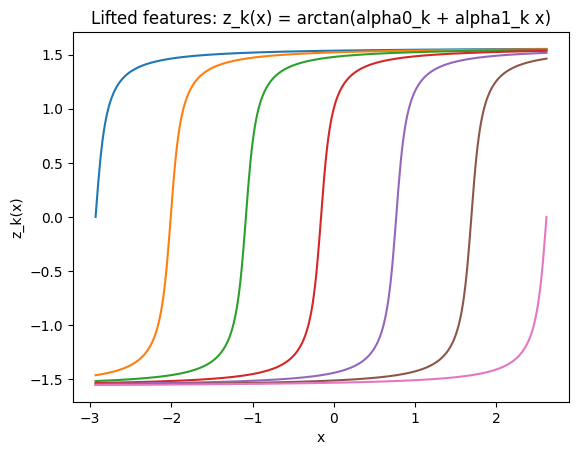

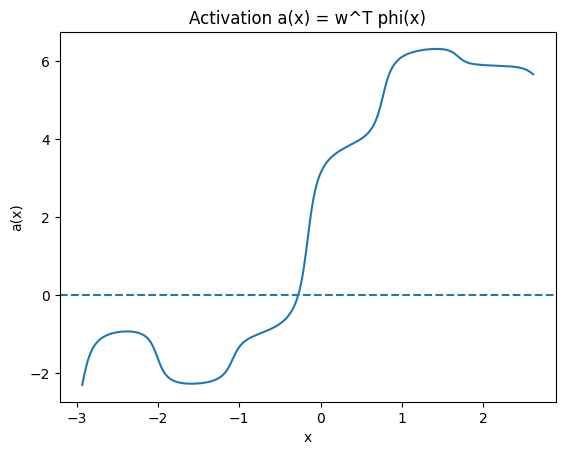

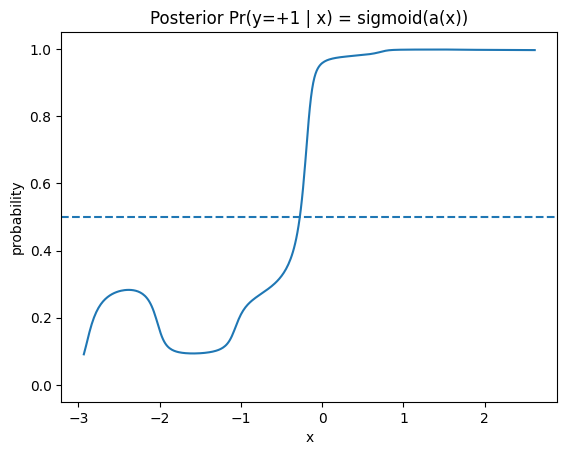

In [8]:
def make_arctan_lift(x, K=7, alpha1_val=10.0, centers=None):
    """
    x: (N,) 1D inputs
    Returns:
      Phi: (K+1, N) lifted design matrix with bias in first row
      alpha0, alpha1: parameters of arctan bases (K,)
    """
    x = np.ravel(x)
    N = x.size

    if centers is None:
        # choose centers spread across the data range
        centers = np.linspace(x.min(), x.max(), K)

    alpha1 = np.full(K, float(alpha1_val))
    alpha0 = -alpha1 * centers  # so that alpha0_k + alpha1_k * x = 0 at x = center_k

    Z = np.arctan(alpha0[:, None] + alpha1[:, None] * x[None, :])  # (K, N)
    Phi = np.vstack([np.ones(N), Z])  # (K+1, N)
    return Phi, alpha0, alpha1

def sigmoid(t):
    return 1.0 / (1.0 + np.exp(-t))

# ---- Use our existing 1D training data from Part 1 ----
# we already have:
#   trn_x (N,), norm_parameters
#   tst_x (M,)
#   trn['labels'] in {-1,+1}, tst['labels'] in {-1,+1}

K = 7

# Lift training/test
Phi_trn, alpha0, alpha1 = make_arctan_lift(trn_x, K=K, alpha1_val=10.0)
Phi_tst, _, _ = make_arctan_lift(tst_x, K=K, alpha1_val=10.0, centers=(-alpha0/alpha1))

# Train logistic regression in lifted space
np.random.seed(1)
w_init = np.random.rand(Phi_trn.shape[0])
epsilon = 1e-2
w_hat, wt, Et = logistic_loss_gradient_descent(Phi_trn, trn["labels"], w_init, epsilon)

# Test error
pred_tst = classify_images(Phi_tst, w_hat)
test_err = np.mean(pred_tst != tst["labels"])
print(f"Bonus (lifted) test error: {test_err*100:.2f}%")

# ---- Plots to verify it behaves as expected ----
xg = np.linspace(min(trn_x.min(), tst_x.min()), max(trn_x.max(), tst_x.max()), 400)
Phi_g, _, _ = make_arctan_lift(xg, K=K, alpha1_val=10.0, centers=(-alpha0/alpha1))

a_g = w_hat @ Phi_g                # activation
p_g = sigmoid(a_g)                 # Pr(y=+1 | x) since labels are {-1,+1}

# Plot basis functions z_k(x)
plt.figure()
for k in range(K):
    zk = Phi_g[1 + k, :]
    plt.plot(xg, zk)
plt.title("Lifted features: z_k(x) = arctan(alpha0_k + alpha1_k x)")
plt.xlabel("x")
plt.ylabel("z_k(x)")
plt.show()

# Plot activation and posterior
plt.figure()
plt.plot(xg, a_g)
plt.axhline(0.0, linestyle="--")
plt.title("Activation a(x) = w^T phi(x)")
plt.xlabel("x")
plt.ylabel("a(x)")
plt.show()

plt.figure()
plt.plot(xg, p_g)
plt.axhline(0.5, linestyle="--")
plt.title("Posterior Pr(y=+1 | x) = sigmoid(a(x))")
plt.xlabel("x")
plt.ylabel("probability")
plt.ylim(-0.05, 1.05)
plt.show()
